# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import build_random_dag, generate_random_dataset, load_sachs, load_cancer, load_child
from reporting import plot_hyperparam_sensitivity, print_summary, METRIC_COLUMNS
from training import grid_search

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-06-29 10:06:50,756 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-06-29 10:06:50,772 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[METRIC_COLUMNS].mean().reset_index()
        if other else results_df
    )


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


def search_and_report(df, gt_dag, param_grid, algorithm: str):
    best_result, results_df = grid_search(df, algorithm, param_grid, gt_dag)
    best_params = results_df.loc[results_df["shd"].idxmin(), list(param_grid.keys())].to_dict()
    print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
    print(results_df)

    plot_hyperparam_sensitivity(results_df)
    # plot_scatter(results_df, param_grid)
    print_summary(results_df)


## Sachs et al.

This section of the notebook contains hyper-parameter search for the Sachs et al. protein dataset (11 variables)

In [32]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")


Sachs: 11672 samples, 11 nodes, 20 true edges


### NOTEARS

Grid search over the following NOTEARS hyperparameters:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `\|weight\| < w_threshold` are pruned |

In [33]:
SACHS_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

best_result_sachs, results_df_sachs = grid_search(sachs_df, "notears", SACHS_PARAM_GRID, sachs_dag)
best_params_sachs = results_df_sachs.loc[results_df_sachs["shd"].idxmin(), list(SACHS_PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df_sachs['shd'].min():.0f}  params: {best_params_sachs}")
results_df_sachs

2026-06-28 17:00:22,392 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-06-28 17:00:23,779 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-06-28 17:00:23,854 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.492e+00, loss=259284.164, rho=1.0e+00
2026-06-28 17:00:24,085 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259312.179, rho=1.0e+01
2026-06-28 17:00:24,610 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259592.326, rho=1.0e+02
2026-06-28 17:00:25,235 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Best SHD: 20  params: {'lambda1': 0.01, 'w_threshold': 0.5}


,lambda1,w_threshold,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,0.01,0.1,27,26,0.259259,0.35,0.297872,7,13,6,7
1,0.01,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
2,0.01,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
3,0.01,0.5,13,20,0.384615,0.25,0.303030,5,5,12,3
4,0.05,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
5,0.05,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
6,0.05,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
7,0.05,0.5,12,20,0.416667,0.25,0.312500,5,5,13,2
8,0.10,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
9,0.10,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5


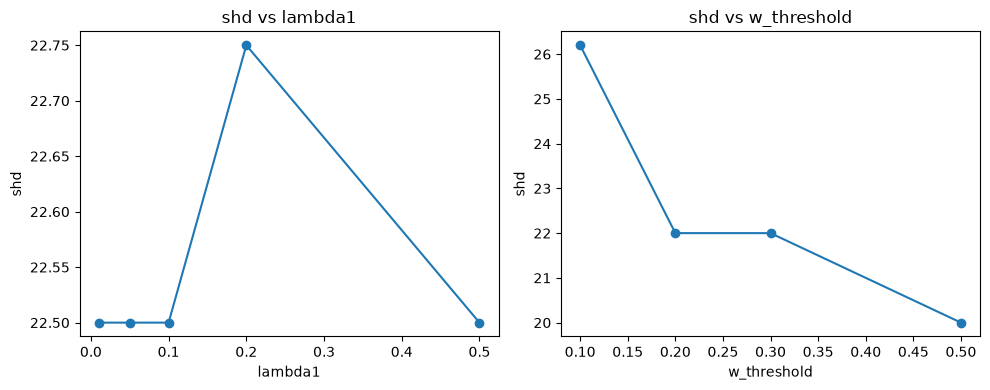

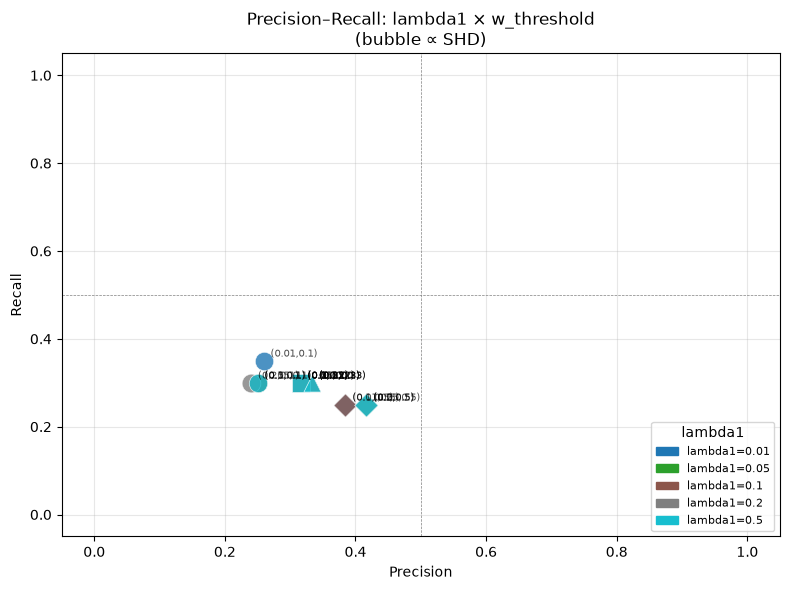

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.5 0.303      0.385    0.25   20         13
    0.05          0.5 0.312      0.417    0.25   20         12
    0.20          0.5 0.312      0.417    0.25   20         12
    0.10          0.5 0.303      0.385    0.25   20         13
    0.50          0.5 0.312      0.417    0.25   20         12

Recommended: lambda1=0.01, w_threshold=0.5
  F1=0.303  Precision=0.385  Recall=0.250  SHD=20


In [35]:
plot_hyperparam_sensitivity(results_df_sachs)
plot_scatter(results_df_sachs, SACHS_PARAM_GRID)
print_summary(results_df_sachs)


### PC

Grid search over the following PC hyperparameters on the real Sachs et al. dataset:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

Grid: 1 × 6 × 4 = 24 combinations



2026-06-28 17:58:15,216 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:18,798 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:23,970 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:30,261 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:32,385 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 30  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': nan}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         36   35   0.250000   
1   pearsonr               0.001            3.0         29   31   0.241379   
2   pearsonr               0.001            4.0         29   31   0.241379   
3   pearsonr               0.001            NaN         28   30   0.250000   
4   pearsonr               0.005            2.0         36   35   0.250000   
5   pearsonr               0.005            3.0         36   35   0.250000   
6   pearsonr               0.005            4.0         30   33   0.166667   
7   pearsonr               0.005            NaN         31   33   0.225806   
8   pearsonr               0.010            2.0         46   42   0.260870   
9   pearsonr               0.010            3.0         36   36   0.222222   
10  pearsonr               0.010            4

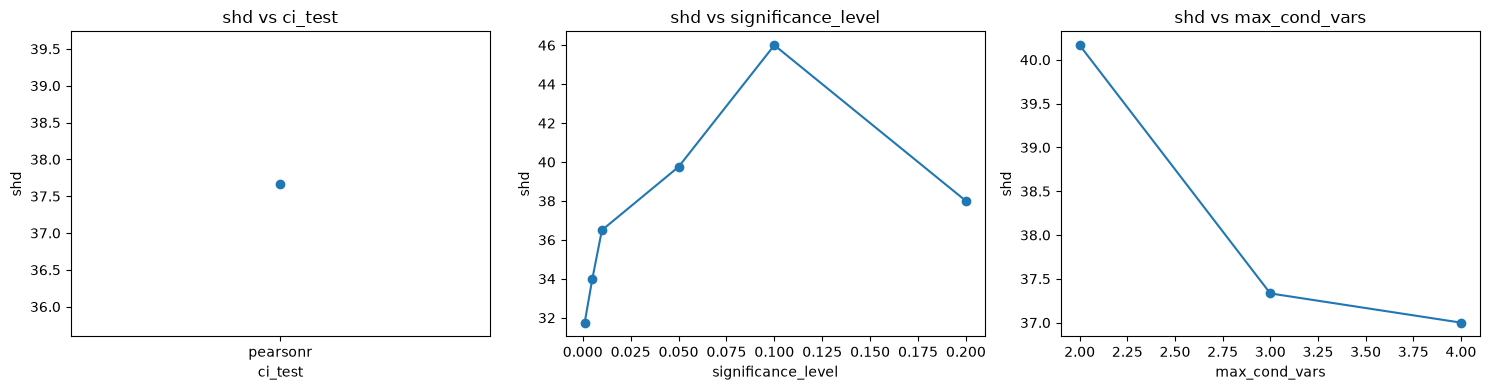

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            NaN 0.275      0.250   0.304   30         28
pearsonr               0.001            3.0 0.269      0.241   0.304   31         29
pearsonr               0.001            4.0 0.269      0.241   0.304   31         29
pearsonr               0.010            NaN 0.286      0.250   0.333   32         32
pearsonr               0.005            4.0 0.192      0.167   0.227   33         30

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=nan
  F1=0.275  Precision=0.250  Recall=0.304  SHD=30


In [48]:
PC_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(sachs_df, sachs_dag, PC_PARAM_GRID, "pc")

### FGES

Grid search over the following GES hyperparameters on the real Sachs et al. dataset:

| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

In [43]:
FGES_SACHS_PARAM_GRID = {
    "method": ["scatter", "r2"],
}

best_result_fges_sachs, results_df_fges_sachs = grid_search(sachs_df, "fges", FGES_SACHS_PARAM_GRID, sachs_dag)
best_params_fges_sachs = results_df_fges_sachs.loc[
    results_df_fges_sachs["shd"].idxmin(), list(FGES_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_fges_sachs['shd'].min():.0f}  params: {best_params_fges_sachs}")
results_df_fges_sachs

Grid: 2 = 2 combinations

Best SHD: 26  params: {'method': 'r2'}


,method,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,scatter,35,33,0.228571,0.363636,0.280702,8,19,6,8
1,r2,20,26,0.363636,0.285714,0.320000,8,6,12,8


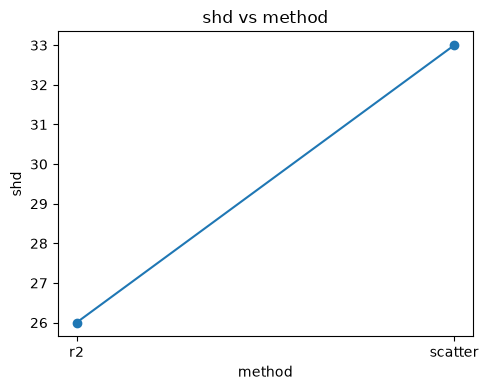

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
     r2 0.320      0.364   0.286   26         20
scatter 0.281      0.229   0.364   33         35

Recommended: method=r2
  F1=0.320  Precision=0.364  Recall=0.286  SHD=26


In [ ]:
plot_hyperparam_sensitivity(results_df_fges_sachs)
print_summary(results_df_fges_sachs)


## Cancer

This section of the notebook contains hyper-parameter search for the cancer dataset (5 variables)


In [3]:
cancer_df, cancer_dag = load_cancer(1000, SEED)
print(f"Cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 31.23it/s] 

Cancer: 1000 samples, 5 nodes, 4 true edges


### NOTEARS

Grid search over the following NOTEARS hyperparameters on the Cancer dataset:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `\|weight\| < w_threshold` are pruned |

2026-06-29 10:04:12,764 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-06-29 10:04:12,805 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,808 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,811 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-06-29 10:04:12,813 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Grid: 5 × 4 = 20 combinations



2026-06-29 10:04:12,967 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,970 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-06-29 10:04:12,973 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+02
2026-06-29 10:04:12,976 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+03
2026-06-29 10:04:12,979 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 3  params: {'lambda1': 0.01, 'w_threshold': 0.1}
    lambda1  w_threshold  n_learned  shd  precision  recall   f1  tp  fp  fn  \
0      0.01          0.1          1    3        1.0    0.25  0.4   1   0   3   
1      0.01          0.2          0    4        0.0    0.00  0.0   0   0   4   
2      0.01          0.3          0    4        0.0    0.00  0.0   0   0   4   
3      0.01          0.5          0    4        0.0    0.00  0.0   0   0   4   
4      0.05          0.1          0    4        0.0    0.00  0.0   0   0   4   
5      0.05          0.2          0    4        0.0    0.00  0.0   0   0   4   
6      0.05          0.3          0    4        0.0    0.00  0.0   0   0   4   
7      0.05          0.5          0    4        0.0    0.00  0.0   0   0   4   
8      0.10          0.1          0    4        0.0    0.00  0.0   0   0   4   
9      0.10          0.2          0    4        0.0    0.00  0.0   0   0   4   
10     0.10          0.3          0    4        0.0    0.00  

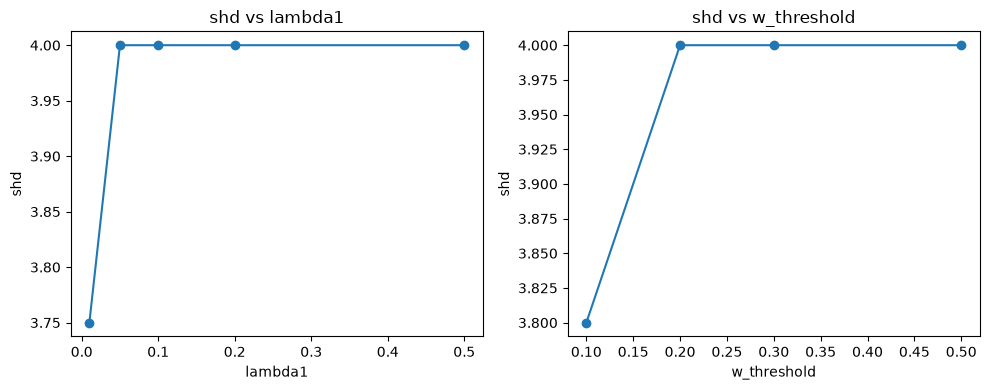

Top 5 combinations by shd
 lambda1  w_threshold  f1  precision  recall  shd  n_learned
    0.01          0.1 0.4        1.0    0.25    3          1
    0.01          0.2 0.0        0.0    0.00    4          0
    0.01          0.3 0.0        0.0    0.00    4          0
    0.01          0.5 0.0        0.0    0.00    4          0
    0.05          0.1 0.0        0.0    0.00    4          0

Recommended: lambda1=0.01, w_threshold=0.1
  F1=0.400  Precision=1.000  Recall=0.250  SHD=3


In [ ]:
NOTEARS_CANCER_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(cancer_df, cancer_dag, NOTEARS_CANCER_PARAM_GRID, "notears")

### PC

Grid search over the following PC hyperparameters on the Cancer dataset:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (`"pearsonr"` for continuous Gaussian data) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

2026-06-29 10:07:01,690 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting


Grid: 1 × 6 × 4 = 24 combinations



2026-06-29 10:07:01,847 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:01,899 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,062 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,135 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,221 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 2  params: {'ci_test': 'pearsonr', 'significance_level': 0.005, 'max_cond_vars': 2.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0          2    3   0.500000   
1   pearsonr               0.001            3.0          2    3   0.500000   
2   pearsonr               0.001            4.0          2    3   0.500000   
3   pearsonr               0.001            NaN          2    3   0.500000   
4   pearsonr               0.005            2.0          3    2   0.666667   
5   pearsonr               0.005            3.0          3    2   0.666667   
6   pearsonr               0.005            4.0          3    2   0.666667   
7   pearsonr               0.005            NaN          3    2   0.666667   
8   pearsonr               0.010            2.0          4    2   0.500000   
9   pearsonr               0.010            3.0          4    2   0.500000   
10  pearsonr               0.010            4.

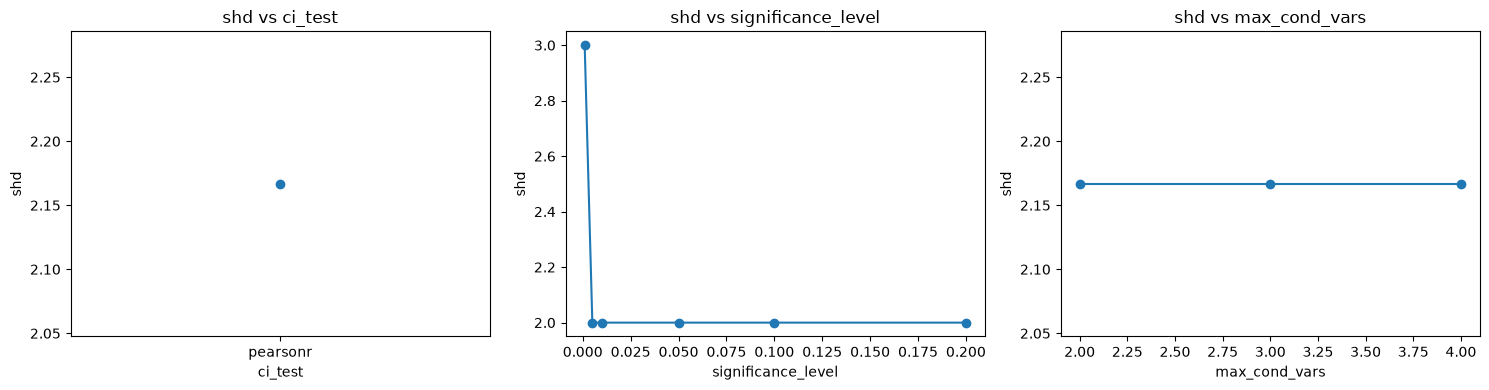

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.005            NaN 0.571      0.667     0.5    2          3
pearsonr               0.005            4.0 0.571      0.667     0.5    2          3
pearsonr               0.005            3.0 0.571      0.667     0.5    2          3
pearsonr               0.005            2.0 0.571      0.667     0.5    2          3
pearsonr               0.010            NaN 0.500      0.500     0.5    2          4

Recommended: ci_test=pearsonr, significance_level=0.005, max_cond_vars=nan
  F1=0.571  Precision=0.667  Recall=0.500  SHD=2


In [4]:
PC_CANCER_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(cancer_df, cancer_dag, PC_CANCER_PARAM_GRID, "pc")

### FGES

Grid search over the following FGES hyperparameters on the Cancer dataset:

| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

Grid: 2 = 2 combinations

Best SHD: 1  params: {'method': 'scatter'}
    method  n_learned  shd  precision  recall        f1  tp  fp  fn  reversed
0  scatter          4    1   0.750000    0.75  0.750000   3   0   0         1
1       r2         11   13   0.090909    0.25  0.133333   1  10   3         0


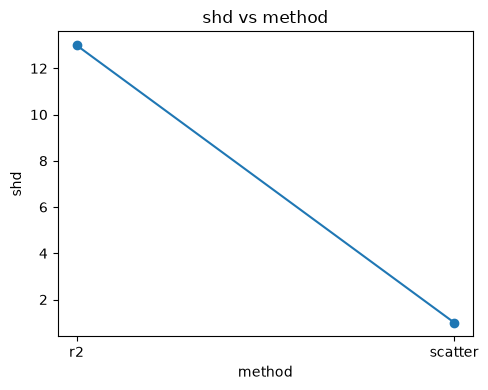

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.750      0.750    0.75    1          4
     r2 0.133      0.091    0.25   13         11

Recommended: method=scatter
  F1=0.750  Precision=0.750  Recall=0.750  SHD=1


In [5]:
FGES_CANCER_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(cancer_df, cancer_dag, FGES_CANCER_PARAM_GRID, "fges")

## Child

This section of the notebook contains hyper-parameter search for the Child dataset (20 variables)

In [9]:
child_df, child_dag = load_child(5000, SEED)
print(f"Child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-06-29 10:10:15,707 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-06-29 10:10:15,707 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 256.51it/s]

Child: 5000 samples, 20 nodes, 25 true edges


### NOTEARS

Grid search over the following NOTEARS hyperparameters on the Child dataset:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `\|weight\| < w_threshold` are pruned |

2026-06-29 10:10:18,741 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=5000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-06-29 10:10:19,193 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.774e-01, loss=7.408, rho=1.0e+00
2026-06-29 10:10:19,642 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.036e-01, loss=4.130, rho=1.0e+00
2026-06-29 10:10:20,363 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.876e-02, loss=4.476, rho=1.0e+01
2026-06-29 10:10:21,450 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.470e-02, loss=7.938, rho=1.0e+02
2026-06-29 10:10:21,608 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 21  params: {'lambda1': 0.05, 'w_threshold': 0.3}
    lambda1  w_threshold  n_learned  shd  precision  recall        f1  tp  fp  \
0      0.01          0.1         32   27   0.281250    0.36  0.315789   9  11   
1      0.01          0.2         24   24   0.291667    0.28  0.285714   7   6   
2      0.01          0.3         18   23   0.333333    0.24  0.279070   6   4   
3      0.01          0.5         15   22   0.333333    0.20  0.250000   5   2   
4      0.05          0.1         22   23   0.318182    0.28  0.297872   7   5   
5      0.05          0.2         19   22   0.315789    0.24  0.272727   6   3   
6      0.05          0.3         13   21   0.384615    0.20  0.263158   5   1   
7      0.05          0.5          9   22   0.444444    0.16  0.235294   4   1   
8      0.10          0.1         15   22   0.333333    0.20  0.250000   5   2   
9      0.10          0.2         11   22   0.363636    0.16  0.222222   4   1   
10     0.10          0.3         11   22   0.3636

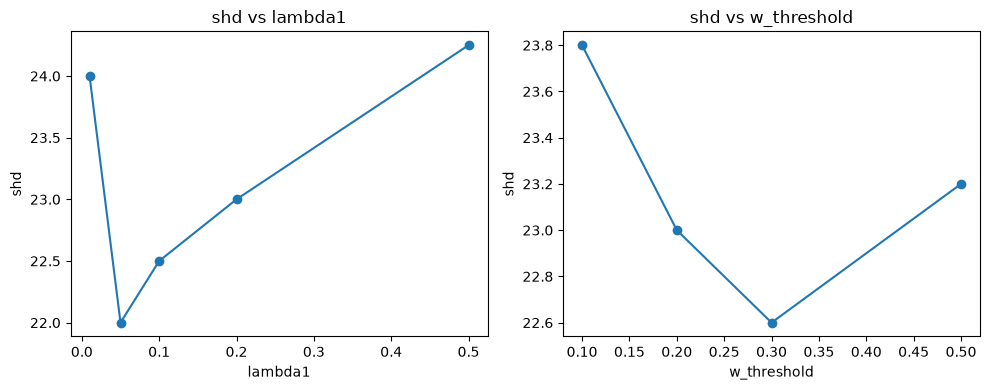

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.05          0.3 0.263      0.385    0.20   21         13
    0.01          0.5 0.250      0.333    0.20   22         15
    0.05          0.2 0.273      0.316    0.24   22         19
    0.05          0.5 0.235      0.444    0.16   22          9
    0.10          0.2 0.222      0.364    0.16   22         11

Recommended: lambda1=0.05, w_threshold=0.3
  F1=0.263  Precision=0.385  Recall=0.200  SHD=21


In [10]:
NOTEARS_CHILD_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(child_df, child_dag, NOTEARS_CHILD_PARAM_GRID, "notears")

### PC

Grid search over the following PC hyperparameters on the Child dataset:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (`"pearsonr"` for continuous Gaussian data) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

Grid: 1 × 6 × 4 = 24 combinations



2026-06-29 11:01:40,961 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:43,914 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:47,073 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:50,373 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:53,588 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 29  params: {'ci_test': 'pearsonr', 'significance_level': 0.05, 'max_cond_vars': 4.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         37   33   0.270270   
1   pearsonr               0.001            3.0         37   33   0.270270   
2   pearsonr               0.001            4.0         37   33   0.270270   
3   pearsonr               0.001            NaN         37   33   0.270270   
4   pearsonr               0.005            2.0         37   32   0.297297   
5   pearsonr               0.005            3.0         37   32   0.297297   
6   pearsonr               0.005            4.0         37   32   0.297297   
7   pearsonr               0.005            NaN         37   32   0.297297   
8   pearsonr               0.010            2.0         36   32   0.277778   
9   pearsonr               0.010            3.0         35   31   0.285714   
10  pearsonr               0.010            4.

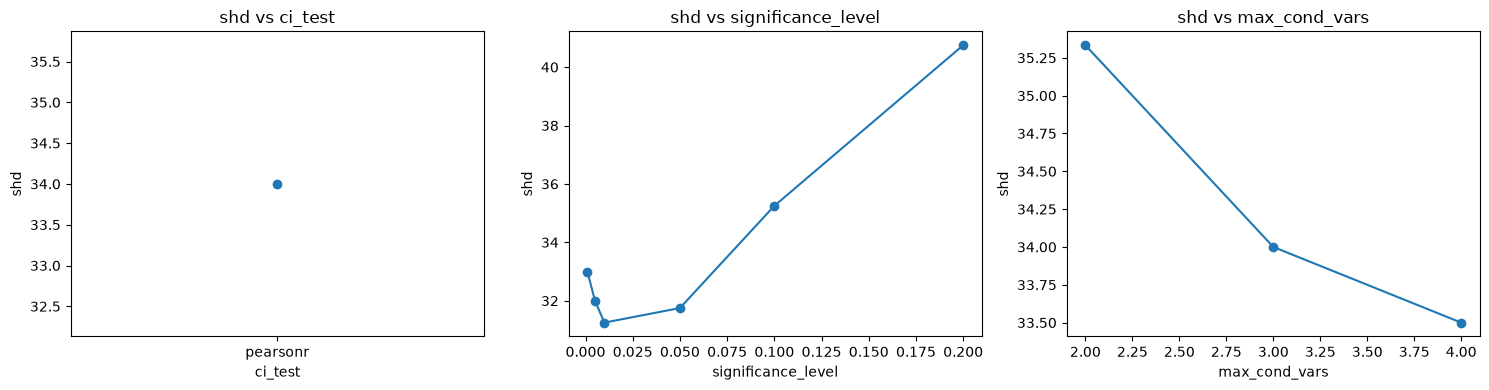

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr                0.05            NaN 0.393      0.343   0.462   29         35
pearsonr                0.05            4.0 0.393      0.343   0.462   29         35
pearsonr                0.01            4.0 0.317      0.286   0.357   31         35
pearsonr                0.01            3.0 0.317      0.286   0.357   31         35
pearsonr                0.01            NaN 0.317      0.286   0.357   31         35

Recommended: ci_test=pearsonr, significance_level=0.05, max_cond_vars=nan
  F1=0.393  Precision=0.343  Recall=0.462  SHD=29


In [11]:
PC_CHILD_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(child_df, child_dag, PC_CHILD_PARAM_GRID, "pc")

### FGES

Grid search over the following FGES hyperparameters on the Child dataset:

| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

Grid: 2 = 2 combinations

Best SHD: 36  params: {'method': 'scatter'}
    method  n_learned  shd  precision    recall        f1  tp  fp  fn  \
0  scatter         50   36   0.320000  0.592593  0.415584  16  25   2   
1       r2         47   64   0.042553  0.074074  0.054054   2  39  19   

   reversed  
0         9  
1         6  


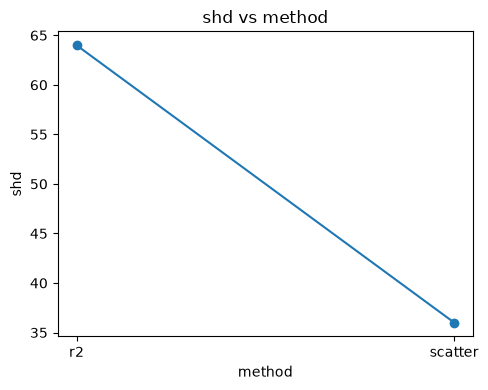

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.416      0.320   0.593   36         50
     r2 0.054      0.043   0.074   64         47

Recommended: method=scatter
  F1=0.416  Precision=0.320  Recall=0.593  SHD=36


In [12]:
FGES_CHILD_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(child_df, child_dag, FGES_CHILD_PARAM_GRID, "fges")